# MLE Optimization of changepoint

In [8]:
import numpy as np
from scipy.optimize import minimize

# 1. GENERATE DUMMY DATA
np.random.seed(42)
n = 100
true_tau = 45.0
true_theta1 = 2.0
true_theta2 = 7.0
true_s = 1.0  # Sharp transition

# Generate time steps and smooth true parameters
t = np.arange(1, n + 1)
w_true = 1 / (1 + np.exp(-(t - true_tau) / true_s))
theta_true = (1 - w_true) * true_theta1 + w_true * true_theta2

# Sample Poisson counts
X = np.random.poisson(theta_true)

# 2. DEFINE OBJECTIVE FUNCTION & GRADIENTS
def loss_and_gradient(params, X, t):
    """
    Computes Negative Log-Likelihood and its gradient for a
    smooth single-changepoint Poisson model.
    """
    theta1, theta2, tau, s = params

    # Avoid division by zero or log of negative numbers
    theta1 = max(theta1, 1e-5)
    theta2 = max(theta2, 1e-5)
    s = max(s, 1e-5)

    # Sigmoid weights and effective theta(t)
    w = 1 / (1 + np.exp(-(t - tau) / s))
    theta_t = (1 - w) * theta1 + w * theta2

    # Negative Log-Likelihood (Minimize NLL to Maximize Likelihood)
    nll = -np.sum(X * np.log(theta_t) - theta_t)

    # Common prediction error term
    pred_error = (X / theta_t) - 1.0

    # Gradients with respect to each parameter
    d_theta1 = -np.sum(pred_error * (1 - w))
    d_theta2 = -np.sum(pred_error * w)

    # Derivative of w(t) w.r.t tau and s
    dw_dtau = -(1/s) * w * (1 - w)
    dw_ds = -w * (1 - w) * ((t - tau) / (s**2))

    # Chain rule parts for tau and s via theta(t)
    dtheta_dw = theta2 - theta1

    d_tau = -np.sum(pred_error * dtheta_dw * dw_dtau)
    d_s = -np.sum(pred_error * dtheta_dw * dw_ds)

    grad = np.array([d_theta1, d_theta2, d_tau, d_s])
    return nll, grad

# 3. RUN THE ITERATIVE OPTIMIZATION
# Initial guesses: [theta1, theta2, tau, s]
# Start tau at 50 (midpoint) and s at 2.0 (slightly smoother start)
initial_guess = [np.mean(X[:50]), np.mean(X[50:]), 50.0, 2.0]

# Define bounds to prevent unphysical values (e.g., negative rates or s)
bounds = [(1e-3, None), (1e-3, None), (1, n), (0.1, 10.0)]

print("Optimizing parameters using L-BFGS-B...")
result = minimize(
    fun=loss_and_gradient,
    x0=initial_guess,
    args=(X, t),
    jac=True,  # Tell scipy we are providing the analytical gradient vector
    method='L-BFGS-B',
    bounds=bounds
)

# 4. DISPLAY RESULTS
if result.success:
    est_theta1, est_theta2, est_tau, est_s = result.x
    print("\nOptimization Successful!")
    print(f"{'Parameter':<12} | {'True Value':<10} | {'Estimated MLE':<15}")
    print("-" * 45)
    print(f"{'theta1':<12} | {true_theta1:<10} | {est_theta1:.4f}")
    print(f"{'theta2':<12} | {true_theta2:<10} | {est_theta2:.4f}")
    print(f"{'tau':<12} | {true_tau:<10} | {est_tau:.4f}")
    print(f"{'s':<12} | {true_s:<10} | {est_s:.4f}")
else:
    print("Optimization failed:", result.message)

Optimizing parameters using L-BFGS-B...

Optimization Successful!
Parameter    | True Value | Estimated MLE  
---------------------------------------------
theta1       | 2.0        | 2.0630
theta2       | 7.0        | 7.1640
tau          | 45.0       | 45.8638
s            | 1.0        | 1.4539


# Plot MLE Changepoint

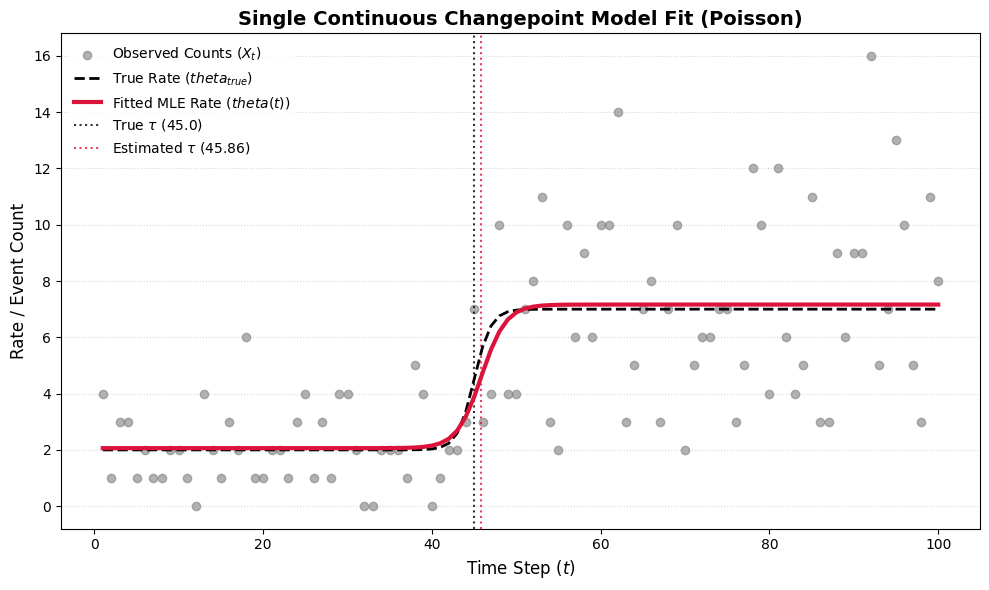

In [9]:
import matplotlib.pyplot as plt

# Ensure you run this code in the same session after running the optimization script above,
# as it relies on the variables (t, X, theta_true, true_tau, result) defined there.

if result.success:
    # Extract optimized parameters
    est_theta1, est_theta2, est_tau, est_s = result.x

    # Compute the fitted MLE parameter curve over time
    w_est = 1 / (1 + np.exp(-(t - est_tau) / est_s))
    theta_est = (1 - w_est) * est_theta1 + w_est * est_theta2

    # Plotting
    plt.figure(figsize=(10, 6))

    # 1. Plot the raw simulated count data
    plt.scatter(t, X, color='gray', alpha=0.6, label='Observed Counts ($X_t$)', zorder=2)

    # 2. Plot the true generative rate
    plt.plot(t, theta_true, color='black', linestyle='--', linewidth=2, label='True Rate ($theta_{true}$)', zorder=3)

    # 3. Plot the fitted MLE rate
    plt.plot(t, theta_est, color='crimson', linewidth=3, label='Fitted MLE Rate ($theta(t)$)', zorder=4)

    # 4. Mark the true vs estimated changepoint locations
    plt.axvline(true_tau, color='black', linestyle=':', alpha=0.8, label=f'True $\\tau$ ({true_tau})')
    plt.axvline(est_tau, color='crimson', linestyle=':', alpha=0.8, label=f'Estimated $\\tau$ ({est_tau:.2f})')

    # Aesthetic adjustments
    plt.title('Single Continuous Changepoint Model Fit (Poisson)', fontsize=14, fontweight='bold')
    plt.xlabel('Time Step ($t$)', fontsize=12)
    plt.ylabel('Rate / Event Count', fontsize=12)
    plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
    plt.grid(axis='y', linestyle=':', alpha=0.5)

    plt.tight_layout()
    plt.show()
else:
    print("Optimization was not successful; cannot plot fit.")

# Estimate Uncertainty using Laplace Approximation

In [14]:
from scipy.optimize import approx_fprime

# Ensure this runs after the optimization script where 'result', 'X', and 't' are defined.
if result.success:
    # 1. EXTRACT THE MAP ESTIMATE (THE PEAK)
    map_estimate = result.x

    # 2. DEFINE A WRAPPER FOR THE GRADIENT ONLY
    # approx_fprime requires a function that returns a 1D array of gradients
    def gradient_wrapper(params):
        _, grad = loss_and_gradient(params, X, t)
        return grad

    # 3. COMPUTE THE HESSIAN VIA FINITE DIFFERENCES OF THE GRADIENT
    # We use a small epsilon step size to evaluate the slope of the gradient
    epsilon = 1e-5
    print("Computing numerical Hessian matrix at the peak...")

    # approx_fprime evaluates the jacobian of our gradient function, which IS the Hessian
    hessian_nll = np.array([
        approx_fprime(map_estimate, lambda p: gradient_wrapper(p)[i], epsilon)
        for i in range(len(map_estimate))
    ])

    # Symmetrize the matrix to eliminate tiny numerical float asymmetries
    hessian_nll = (hessian_nll + hessian_nll.T) / 2.0

    # 4. CONVERT HESSIAN TO BAYESIAN COVARIANCE
    # Since our loss function is the NEGATIVE log-likelihood, our hessian_nll is already -H.
    # Therefore, Covariance = Inverse(Hessian of NLL)
    try:
        covariance_matrix = np.linalg.inv(hessian_nll)

        # The diagonal elements represent the variances of our parameters
        parameter_variances = np.diag(covariance_matrix)

        # Handle tiny negative numbers that can occur due to numerical noise near 0
        parameter_variances = np.clip(parameter_variances, 0, None)
        standard_errors = np.sqrt(parameter_variances)

        # 5. DISPLAY THE BAYESIAN UNCERTAINTY
        param_names = ['theta1', 'theta2', 'tau', 's']
        print("\nLaplace Approximation Results:")
        print(f"{'Parameter':<12} | {'MAP Estimate':<15} | {'95% Credible Interval (±1.96 SE)':<30}")
        print("-" * 65)
        for i, name in enumerate(param_names):
            mean = map_estimate[i]
            se = standard_errors[i]
            ci_lower = mean - 1.96 * se
            ci_upper = mean + 1.96 * se
            print(f"{name:<12} | {mean:<15.4f} | [{ci_lower:.4f}, {ci_upper:.4f}]")

        print("\nParameter Correlation Matrix:")
        # Normalize covariance matrix to get correlations
        d = np.diag(1.0 / (standard_errors + 1e-12))
        correlation_matrix = d @ covariance_matrix @ d
        print(np.round(correlation_matrix, 3))

    except np.linalg.LinAlgError:
        print("\nError: Hessian matrix is singular and cannot be inverted. This can happen if the transition parameter 's' is extremely sharp.")
else:
    print("Optimization failed, cannot calculate Laplace approximation.")

Computing numerical Hessian matrix at the peak...

Laplace Approximation Results:
Parameter    | MAP Estimate    | 95% Credible Interval (±1.96 SE)
-----------------------------------------------------------------
theta1       | 2.0630          | [1.6231, 2.5028]
theta2       | 7.1640          | [6.3977, 7.9302]
tau          | 45.8638         | [42.6515, 49.0760]
s            | 1.4539          | [-0.8975, 3.8053]

Parameter Correlation Matrix:
[[ 1.    -0.011  0.089 -0.085]
 [-0.011  1.     0.349  0.295]
 [ 0.089  0.349  1.     0.649]
 [-0.085  0.295  0.649  1.   ]]


# Plot samples from Laplace Posterior

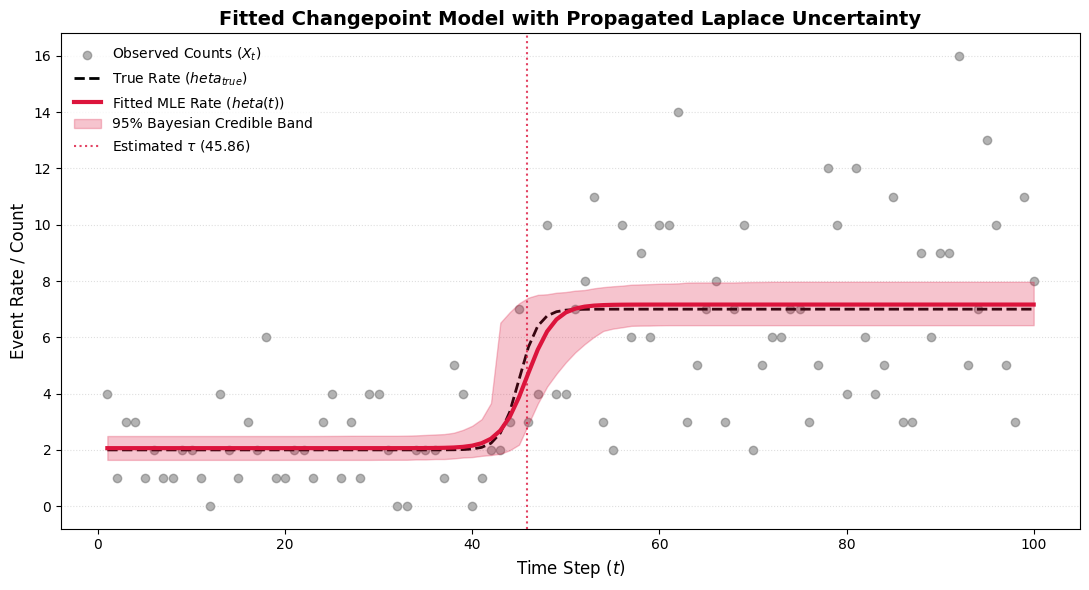

In [11]:
if result.success and 'covariance_matrix' in locals():
    # 1. DRAW SAMPLES FROM THE LAPLACE POSTERIOR
    num_samples = 1000
    # map_estimate and covariance_matrix come from the previous steps
    posterior_samples = np.random.multivariate_normal(
        mean=map_estimate,
        cov=covariance_matrix,
        size=num_samples
    )

    # 2. EVALUATE THETA(T) FOR EVERY POSTERIOR SAMPLE
    # Shape: (num_samples, n_time_steps)
    theta_samples = np.zeros((num_samples, len(t)))

    for i in range(num_samples):
        s1, s2, stau, ss = posterior_samples[i]
        # Guard against unphysical negative values in samples
        s1, s2, ss = max(s1, 1e-3), max(s2, 1e-3), max(ss, 0.1)

        w_sample = 1 / (1 + np.exp(-(t - stau) / ss))
        theta_samples[i, :] = (1 - w_sample) * s1 + w_sample * s2

    # 3. COMPUTE CREDIBLE INTERVALS PER TIME STEP
    # Calculate the mean curve and the 95% boundaries (2.5% to 97.5%)
    mean_theta_mle = theta_est  # From your earlier plotting variables
    lower_bound = np.percentile(theta_samples, 2.5, axis=0)
    upper_bound = np.percentile(theta_samples, 97.5, axis=0)

    # 4. PLOT THE FIT WITH UNCERTAINTY OVERLAY
    plt.figure(figsize=(11, 6))

    # Raw count data
    plt.scatter(t, X, color='dimgray', alpha=0.5, label='Observed Counts ($X_t$)', zorder=1)

    # True generative rate
    plt.plot(t, theta_true, color='black', linestyle='--', linewidth=2, label='True Rate ($\theta_{true}$)', zorder=2)

    # Mean Fitted MLE curve
    plt.plot(t, mean_theta_mle, color='crimson', linewidth=3, label='Fitted MLE Rate ($\theta(t)$)', zorder=4)

    # OVERLAY SHEDED CREDIBLE BAND
    plt.fill_between(
        t, lower_bound, upper_bound,
        color='crimson', alpha=0.25,
        label='95% Bayesian Credible Band', zorder=3
    )

    # Vertical indicator for changepoint location uncertainty
    plt.axvline(est_tau, color='crimson', linestyle=':', alpha=0.8, label=f'Estimated $\\tau$ ({est_tau:.2f})')

    # Aesthetics
    plt.title('Fitted Changepoint Model with Propagated Laplace Uncertainty', fontsize=14, fontweight='bold')
    plt.xlabel('Time Step ($t$)', fontsize=12)
    plt.ylabel('Event Rate / Count', fontsize=12)
    plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
    plt.grid(axis='y', linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.show()
else:
    print("Could not overlay uncertainties because Hessian calculation or optimization failed.")

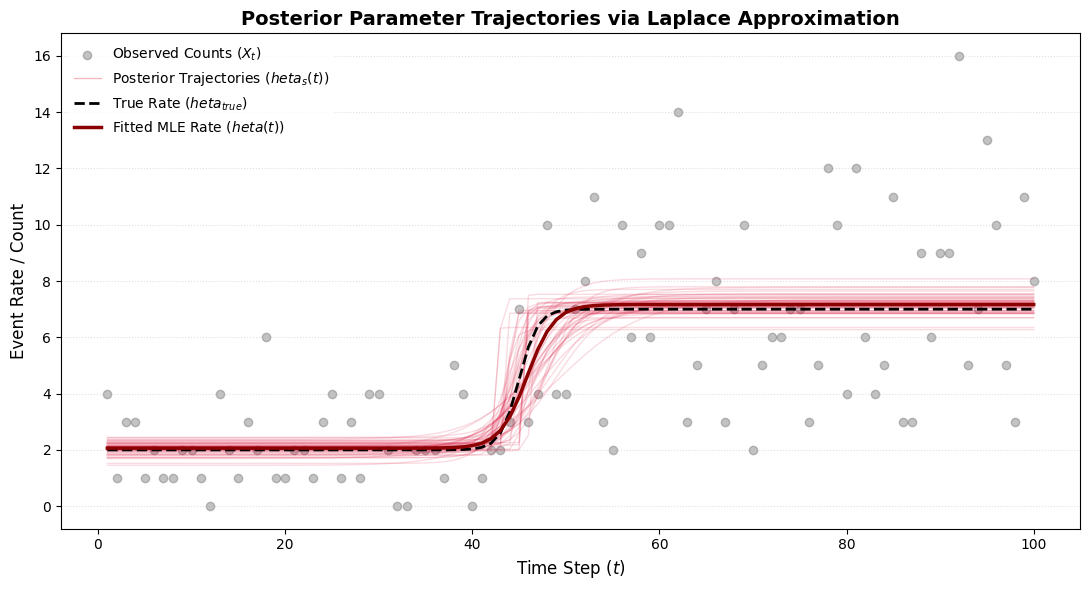

In [13]:
if result.success and 'theta_samples' in locals():
    plt.figure(figsize=(11, 6))

    # 1. Plot the raw simulated count data
    plt.scatter(t, X, color='dimgray', alpha=0.4, label='Observed Counts ($X_t$)', zorder=1)

    # 2. Plot a subset of individual trajectories from the posterior
    # Plotting 50 samples is plenty to show the density without clogging the plot
    num_lines_to_plot = 50
    sampled_indices = np.random.choice(num_samples, size=num_lines_to_plot, replace=False)

    for idx in sampled_indices:
        plt.plot(t, theta_samples[idx, :], color='crimson', alpha=0.15, linewidth=1, zorder=2)

    # Dummy plot element to create a clean single legend entry for the samples
    plt.plot([], [], color='crimson', alpha=0.3, linewidth=1, label='Posterior Trajectories ($\theta_s(t)$)')

    # 3. Plot the true generative rate
    plt.plot(t, theta_true, color='black', linestyle='--', linewidth=2, label='True Rate ($\theta_{true}$)', zorder=3)

    # 4. Plot the mean fitted MLE curve
    plt.plot(t, theta_est, color='darkred', linewidth=2.5, label='Fitted MLE Rate ($\theta(t)$)', zorder=4)

    # Aesthetics
    plt.title('Posterior Parameter Trajectories via Laplace Approximation', fontsize=14, fontweight='bold')
    plt.xlabel('Time Step ($t$)', fontsize=12)
    plt.ylabel('Event Rate / Count', fontsize=12)
    plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
    plt.grid(axis='y', linestyle=':', alpha=0.4)

    plt.tight_layout()
    plt.show()
else:
    print("Could not plot trajectories because posterior sampling array was not found.")